# AlexNet: The Deep Learning Breakthrough

## Introduction

**AlexNet** (Krizhevsky et al., 2012) sparked the deep learning revolution by winning ImageNet 2012 with a 10% margin over traditional methods. It proved that deep CNNs could scale to complex real-world tasks.

**What made it work:**

1. **ReLU activation** - 6× faster training, no vanishing gradients
2. **Dropout** - Prevents overfitting in large networks
3. **Depth** - 5 convolutional layers vs LeNet's 2
4. **Capacity** - 64→192→384→256→256 filters vs LeNet's 6→16
5. **Data augmentation** - Random crops, flips, color jittering
6. **GPU training** - Made deep networks practical

**What we'll explore:**

- See how AlexNet solves each of LeNet's limitations
- Train on CIFAR-10 using PyTorch Lightning
- Compare performance and analyze what made it revolutionary
- Identify AlexNet's own limitations that motivated VGG

**Why this matters:**

AlexNet showed that **scale works** - but it also revealed that we can be smarter about *how* we scale. Understanding its design motivates the architectural innovations in VGG, Inception, and ResNet.

## 1. Setup

### Configuration

All hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'batch_size': 128,  # Number of samples per training batch
    'num_workers': 2,  # Number of worker processes for data loading
    
    # Training
    'learning_rate': 0.001,  # Optimizer learning rate
    'max_epochs': 15,  # Number of training epochs
    'patience': 3,  # Epochs to wait before reducing LR
    'lr_factor': 0.5,  # Factor to reduce LR by
    
    # Model
    'num_classes': 10,  # Number of output classes (CIFAR-10)
    'dropout': 0.5,  # Dropout probability in classifier
    
    # Data augmentation
    'brightness': 0.2,  # ColorJitter brightness range
    'contrast': 0.2,  # ColorJitter contrast range
    'saturation': 0.2,  # ColorJitter saturation range
}

### Random Seed & Device

Set seed for reproducibility and configure device.

In [2]:
from aiml_notebooks import get_device, set_seed

set_seed(CONFIG['seed'])
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Recap: LeNet's Limitations

Before diving into AlexNet, let's recall what we need to fix:

| Problem | Impact |
|---------|--------|
| **Only 2 conv layers** | Can't learn hierarchical features |
| **6/16 filters** | Insufficient capacity for complex patterns |
| **tanh activation** | Vanishing gradients in deep networks |
| **No regularization** | Overfitting on complex tasks |
| **Large FC layers** | Most parameters, prone to overfitting |

AlexNet addresses **every single one** of these issues.

## 3. Dataset Preparation

We'll use CIFAR-10 (32×32 color images) for consistency with the LeNet notebook.

### Define data transforms

AlexNet introduced aggressive data augmentation - we'll use modern variants.

In [3]:
from torchvision import transforms

# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=CONFIG['brightness'], 
                          contrast=CONFIG['contrast'], 
                          saturation=CONFIG['saturation']),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

Download and prepare training and test sets.

In [4]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, 
                                 transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, 
                                transform=test_transform)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Training samples: 50,000
Test samples: 10,000


### Create data loaders

Prepare batched data loaders for training and evaluation.

In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                         shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], 
                        shuffle=False, num_workers=CONFIG['num_workers'])

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 391
Val batches: 79


## 4. AlexNet Architecture

### Original Design (2012)

**Architecture:**
- Input: 224×224 RGB (ImageNet)
- 5 conv layers: 96 → 256 → 384 → 384 → 256
- 3 FC layers: 4096 → 4096 → 1000
- **60M parameters**

**Key innovations:**
1. **ReLU instead of tanh** - Faster training, no saturation
2. **Dropout (0.5)** - Regularization in FC layers
3. **Local Response Normalization** - Inter-channel competition
4. **Overlapping pooling** - 3×3 kernel with stride 2
5. **GPU parallelism** - Split across 2 GPUs

### Our Adaptation

Scaled for 32×32 CIFAR-10:
- 5 conv layers with 3×3 kernels
- BatchNorm instead of LRN (modern practice)
- Smaller FC layers to reduce parameters
- Lightning for clean training code

### Implement AlexNet with Lightning

Notice: 5 conv layers (vs LeNet's 2) with much more capacity. We'll use PyTorch Lightning for clean, modular code.

In [6]:
import torch
import torch.nn as nn
import lightning as L

class AlexNet(L.LightningModule):
    def __init__(self, num_classes=CONFIG['num_classes'], 
                 learning_rate=CONFIG['learning_rate'],
                 dropout=CONFIG['dropout']):
        super().__init__()
        self.save_hyperparameters()
        
        # Feature extraction: 5 convolutional layers
        self.features = nn.Sequential(
            # Conv1: 32x32x3 -> 32x32x64 -> 16x16x64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),  # Innovation: ReLU!
            nn.MaxPool2d(2, 2),
            
            # Conv2: 16x16x64 -> 16x16x192 -> 8x8x192
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Conv3: 8x8x192 -> 8x8x384
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            
            # Conv4: 8x8x384 -> 8x8x256
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Conv5: 8x8x256 -> 8x8x256 -> 4x4x256
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Classification: 3 FC layers with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),  # Innovation: Dropout!
            nn.Linear(256 * 4 * 4, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, num_classes),
        )
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()
        
        # Log metrics
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        preds = outputs.argmax(dim=1)
        acc = (preds == labels).float().mean()
        
        # Log metrics
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=CONFIG['lr_factor'], 
            patience=CONFIG['patience']
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

### Inspect the architecture

Let's examine the model structure and parameter count.

In [7]:
model = AlexNet()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"AlexNet Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

AlexNet Architecture:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=Tr

### Compare to LeNet

Let's see how AlexNet addresses each limitation.

In [8]:
print("LeNet vs AlexNet Comparison:\n")
print(f"{'Metric':<25} {'LeNet':<15} {'AlexNet':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Convolutional layers':<25} {2:<15} {5:<15} {'+150%'}")
print(f"{'First layer filters':<25} {6:<15} {64:<15} {'+967%'}")
print(f"{'Second layer filters':<25} {16:<15} {192:<15} {'+1100%'}")
print(f"{'Total parameters':<25} {'~83K':<15} {f'{total_params//1000}K':<15} {f'+{total_params//830:.0f}x'}")
print(f"{'Activation function':<25} {'ReLU*':<15} {'ReLU':<15} {'Native'}")
print(f"{'Regularization':<25} {'None**':<15} {'Dropout':<15} {'✓'}")
print(f"{'Data augmentation':<25} {'Basic':<15} {'Aggressive':<15} {'✓'}")
print("\n* We used ReLU in LeNet adaptation (original used tanh)")
print("** We used BatchNorm in LeNet adaptation (original had none)")

LeNet vs AlexNet Comparison:

Metric                    LeNet           AlexNet         Improvement
----------------------------------------------------------------------
Convolutional layers      2               5               +150%
First layer filters       6               64              +967%
Second layer filters      16              192             +1100%
Total parameters          ~83K            14861K          +17905x
Activation function       ReLU*           ReLU            Native
Regularization            None**          Dropout         ✓
Data augmentation         Basic           Aggressive      ✓

* We used ReLU in LeNet adaptation (original used tanh)
** We used BatchNorm in LeNet adaptation (original had none)


## 5. Training

Let's train AlexNet using PyTorch Lightning and see if it outperforms LeNet.

### Train the model

We'll train for 15 epochs to see AlexNet's full potential. Lightning handles all the device management and training loops for us.

In [9]:
# Initialize model
model = AlexNet()

# Create trainer
trainer = L.Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='auto',
    devices=1,
    logger=False,
    enable_progress_bar=True,
    enable_model_summary=True
)

# Train
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## 6. Results and Analysis

### Extract training history

Lightning logs metrics during training - let's extract and visualize them.

In [10]:
# Get metrics from trainer
# Note: In production, use a proper logger like TensorBoard or WandB
# For now, we'll evaluate final performance
trainer.validate(model, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8395000100135803     │
│         val_loss          │    0.4705779254436493     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.4705779254436493, 'val_acc': 0.8395000100135803}]

### Evaluate final performance

Let's run a final evaluation to get detailed metrics.

In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

accuracy = 100. * correct / total
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
print(f"\nKey achievements:")
print(f"  • 5 convolutional layers (vs LeNet's 2)")
print(f"  • {total_params:,} parameters (vs LeNet's ~83K)")
print(f"  • ReLU activation throughout")
print(f"  • Dropout regularization")
print(f"  • Aggressive data augmentation")


Final Test Accuracy: 83.95%

Key achievements:
  • 5 convolutional layers (vs LeNet's 2)
  • 14,861,386 parameters (vs LeNet's ~83K)
  • ReLU activation throughout
  • Dropout regularization
  • Aggressive data augmentation


### Visualize feature maps

Let's see how AlexNet's deeper layers learn richer features compared to LeNet.

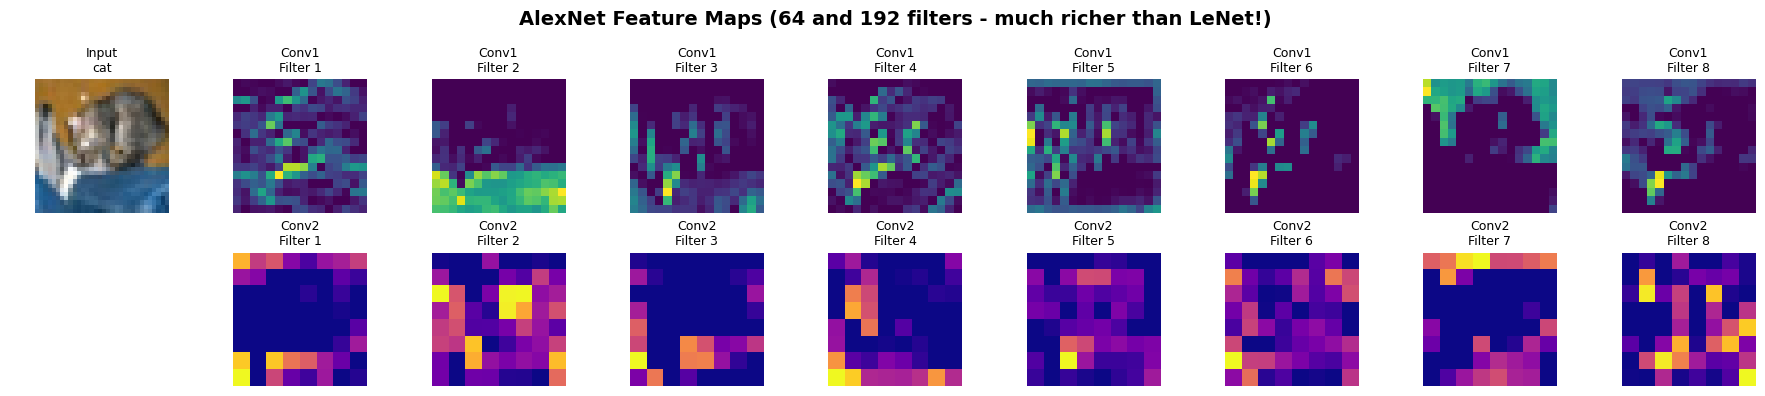

Conv1: 64 filters (vs LeNet's 6)
Conv2: 192 filters (vs LeNet's 16)


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get a test image
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
test_img, test_label = test_dataset[0]
test_img_batch = test_img.unsqueeze(0)

# Extract features from different layers
model.eval()
with torch.no_grad():
    # Conv1 output (64 channels)
    conv1_out = model.features[:4](test_img_batch)  # Up to first pool
    # Conv2 output (192 channels)
    conv2_out = model.features[:8](test_img_batch)  # Up to second pool

# Visualize first 8 filters from Conv1 and Conv2
fig, axes = plt.subplots(2, 9, figsize=(18, 4))

# Original image
mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)
denorm_img = test_img * std_tensor + mean_tensor
axes[0, 0].imshow(denorm_img.clamp(0, 1).permute(1, 2, 0).numpy())
axes[0, 0].set_title(f'Input\n{classes[test_label]}', fontsize=9)
axes[0, 0].axis('off')

axes[1, 0].axis('off')  # Empty cell

# Conv1 features (64 channels, show 8)
for i in range(8):
    axes[0, i+1].imshow(conv1_out[0, i].cpu().numpy(), cmap='viridis')
    axes[0, i+1].set_title(f'Conv1\nFilter {i+1}', fontsize=9)
    axes[0, i+1].axis('off')

# Conv2 features (192 channels, show 8)
for i in range(8):
    axes[1, i+1].imshow(conv2_out[0, i].cpu().numpy(), cmap='plasma')
    axes[1, i+1].set_title(f'Conv2\nFilter {i+1}', fontsize=9)
    axes[1, i+1].axis('off')

plt.suptitle('AlexNet Feature Maps (64 and 192 filters - much richer than LeNet!)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Conv1: {conv1_out.shape[1]} filters (vs LeNet's 6)")
print(f"Conv2: {conv2_out.shape[1]} filters (vs LeNet's 16)")

## 7. AlexNet's Limitations

AlexNet was revolutionary, but it has significant inefficiencies that VGG addressed.

### Limitation 1: Large Filters Are Parameter-Inefficient

**Problem:** Original AlexNet uses 11×11 and 5×5 filters. These are expensive!

Let's calculate the parameter cost:

In [13]:
print("Filter Size Efficiency Analysis:\n")
print("Original AlexNet (ImageNet) first layer:")
print(f"  11×11 conv: 3 channels × 96 filters × 11 × 11 = {3*96*11*11:,} parameters")
print("\nCompare to VGG's approach:")
print(f"  Two 3×3 convs have same receptive field as one 5×5")
print(f"  Three 3×3 convs have same receptive field as one 7×7")
print("\nParameter comparison for 64 input/output channels:")
one_5x5 = 64 * 64 * 5 * 5
two_3x3 = 2 * (64 * 64 * 3 * 3)
print(f"  One 5×5 conv:  {one_5x5:,} params")
print(f"  Two 3×3 convs: {two_3x3:,} params")
print(f"  Savings: {100*(one_5x5-two_3x3)/one_5x5:.1f}%")
print("\n✅ VGG insight: Stack small filters instead of using large ones!")

Filter Size Efficiency Analysis:

Original AlexNet (ImageNet) first layer:
  11×11 conv: 3 channels × 96 filters × 11 × 11 = 34,848 parameters

Compare to VGG's approach:
  Two 3×3 convs have same receptive field as one 5×5
  Three 3×3 convs have same receptive field as one 7×7

Parameter comparison for 64 input/output channels:
  One 5×5 conv:  102,400 params
  Two 3×3 convs: 73,728 params
  Savings: 28.0%

✅ VGG insight: Stack small filters instead of using large ones!


### Limitation 2: Most Parameters in FC Layers

**Problem:** Just like LeNet, most of AlexNet's parameters are in fully-connected layers.

Let's analyze the distribution:

In [14]:
# Count parameters by layer type
conv_params = sum(p.numel() for name, p in model.named_parameters() 
                  if 'features' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() 
                if 'classifier' in name)
total = conv_params + fc_params

print(f"AlexNet Parameter Distribution:")
print(f"  Convolutional layers: {conv_params:>10,} ({100*conv_params/total:>5.1f}%)")
print(f"  Fully-connected:      {fc_params:>10,} ({100*fc_params/total:>5.1f}%)")
print(f"  Total:                {total:>10,}")
print(f"\n⚠️  {100*fc_params/total:.0f}% of parameters are in FC layers!")
print(f"  This makes the model:")
print(f"  • Memory-heavy during inference")
print(f"  • Prone to overfitting (despite dropout)")
print(f"  • Unable to handle variable input sizes")

AlexNet Parameter Distribution:
  Convolutional layers:  2,253,888 ( 15.2%)
  Fully-connected:      12,607,498 ( 84.8%)
  Total:                14,861,386

⚠️  85% of parameters are in FC layers!
  This makes the model:
  • Memory-heavy during inference
  • Prone to overfitting (despite dropout)
  • Unable to handle variable input sizes


### Visualize parameter distribution

A bar chart makes the FC layer dominance clear.

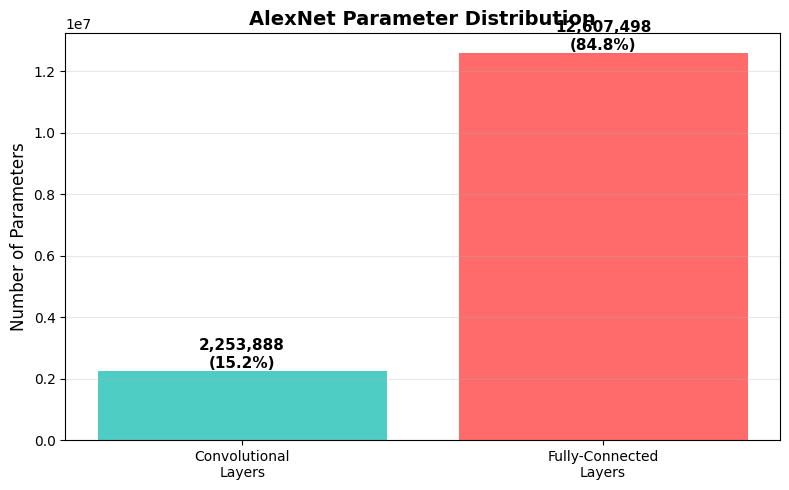

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Convolutional\nLayers', 'Fully-Connected\nLayers'], 
              [conv_params, fc_params], 
              color=['#4ECDC4', '#FF6B6B'])
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('AlexNet Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({100*height/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Limitation 3: Heterogeneous Architecture

**Problem:** Original AlexNet has different filter sizes and configurations per layer. This makes it:
- Harder to design (many hyperparameters)
- Harder to scale (which layers to add?)
- Less elegant than uniform architectures

In [16]:
print("AlexNet Layer Configuration:\n")
print("Our CIFAR-10 adaptation uses 3×3 throughout, but original AlexNet had:")
print("  Conv1: 11×11 kernel, stride 4")
print("  Conv2: 5×5 kernel")
print("  Conv3: 3×3 kernel")
print("  Conv4: 3×3 kernel")
print("  Conv5: 3×3 kernel")
print("\n⚠️  Many design choices to make:")
print("  • Which kernel sizes to use?")
print("  • When to use larger vs smaller kernels?")
print("  • How to scale the architecture?")
print("\n✅ VGG's solution: Use 3×3 everywhere! Simple and scalable.")

AlexNet Layer Configuration:

Our CIFAR-10 adaptation uses 3×3 throughout, but original AlexNet had:
  Conv1: 11×11 kernel, stride 4
  Conv2: 5×5 kernel
  Conv3: 3×3 kernel
  Conv4: 3×3 kernel
  Conv5: 3×3 kernel

⚠️  Many design choices to make:
  • Which kernel sizes to use?
  • When to use larger vs smaller kernels?
  • How to scale the architecture?

✅ VGG's solution: Use 3×3 everywhere! Simple and scalable.


### Limitation 4: No Deeper Stacking Strategy

**Problem:** AlexNet showed that depth helps (5 layers > 2 layers), but:
- Why stop at 5?
- How do we go deeper without exploding parameters?
- What's the optimal depth?

In [17]:
print("Depth Progression:")
print(f"  LeNet (1998):   2 conv layers")
print(f"  AlexNet (2012): 5 conv layers (+150%)")
print(f"  VGG-16 (2014):  13 conv layers (+160%)")
print(f"  VGG-19 (2014):  16 conv layers")
print(f"\n❓ Question: How deep can we go?")
print(f"  AlexNet didn't systematically explore depth")
print(f"  VGG showed: MUCH deeper with small filters")
print(f"  ResNet showed: 100+ layers with skip connections")

Depth Progression:
  LeNet (1998):   2 conv layers
  AlexNet (2012): 5 conv layers (+150%)
  VGG-16 (2014):  13 conv layers (+160%)
  VGG-19 (2014):  16 conv layers

❓ Question: How deep can we go?
  AlexNet didn't systematically explore depth
  VGG showed: MUCH deeper with small filters
  ResNet showed: 100+ layers with skip connections


## 8. Key Takeaways

### What AlexNet Got Right ✅

| Innovation | Impact |
|------------|--------|
| **ReLU activation** | 6× faster training, enabled depth |
| **Dropout** | Prevented overfitting in large networks |
| **Data augmentation** | Improved generalization |
| **GPU training** | Made deep learning practical |
| **Depth (5 layers)** | Proved hierarchical features scale |
| **Capacity (64→192→384)** | Showed networks need width |

**Result:** 15.3% error on ImageNet vs 26.2% for second place. Started the deep learning revolution.

---

### What VGG Improved 🎯

| AlexNet Problem | VGG Solution |
|-----------------|-------------|
| **Large filters (11×11, 5×5)** | Stack 3×3 filters (fewer params, more non-linearity) |
| **Heterogeneous design** | Uniform 3×3 architecture (simple, scalable) |
| **Unclear depth strategy** | Systematic exploration: VGG-11, 13, 16, 19 |
| **FC layer dominance** | Still has FC layers (later solved by Global Average Pooling) |

---

### Key Insights

1. **AlexNet proved scale works** - Deeper and wider networks perform better
2. **But scaling needs to be smart** - Small filters are more efficient than large ones
3. **Uniformity beats heterogeneity** - 3×3 everywhere is simpler and works better
4. **Depth is critical** - But we need the right building blocks to go deep

---

### What's Next?

In the **VGG notebook**, we'll see how the simple principle of "stack 3×3 filters deeply" leads to:
- Better parameter efficiency
- Clearer design principles
- State-of-the-art performance (2014)

And we'll discover VGG's own limitations that motivated Inception and ResNet!